In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix
from qiskit.visualization import plot_state_qsphere
from qiskit_aer import AerSimulator
from qiskit import transpile
import numpy as np
import matplotlib.pyplot as plt

print("All libraries loaded!")

All libraries loaded!


In [ ]:
# Create a circuit with 2 qubits
qc = QuantumCircuit(2)

# Put both qubits into superposition
qc.h(0)   # Hadamard on qubit 0
qc.h(1)   # Hadamard on qubit 1

# Apply 90° phase shift (S gate) to qubit 0
qc.s(0)

# Draw the circuit
print(qc.draw('text'))

     ┌───┐┌───┐
q_0: ┤ H ├┤ S ├
     ├───┤└───┘
q_1: ┤ H ├─────
     └───┘     


In [ ]:
# Calculate the statevector (full quantum state)
state = Statevector(qc)

print("Quantum state amplitudes:")
print(state)

Quantum state amplitudes:
Statevector([0.5+0.j , 0. +0.5j, 0.5+0.j , 0. +0.5j],
            dims=(2, 2))


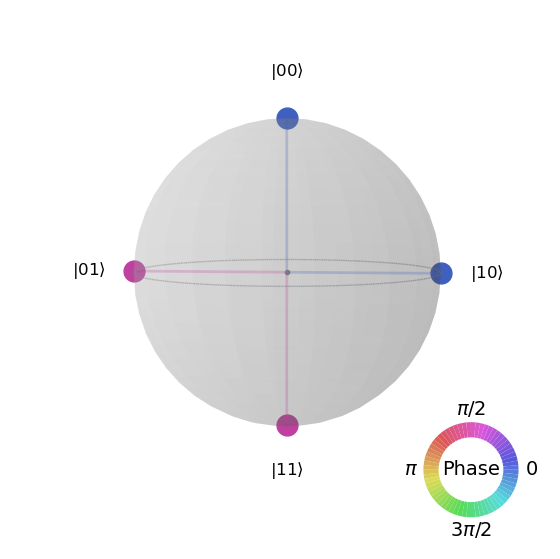

In [ ]:
from qiskit.visualization import plot_state_qsphere

fig = plot_state_qsphere(state)
fig.savefig("qsphere.png", dpi=150, bbox_inches='tight')
fig

In [ ]:
# QASM is a text-based language to describe quantum circuits
# We write the circuit as a string first

qasm_string = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[2];
creg c[2];

h q[0];
cx q[0], q[1];

measure q[0] -> c[0];
measure q[1] -> c[1];
"""

print("QASM circuit written!")
print(qasm_string)

QASM circuit written!

OPENQASM 2.0;
include "qelib1.inc";

qreg q[2];
creg c[2];

h q[0];
cx q[0], q[1];

measure q[0] -> c[0];
measure q[1] -> c[1];



In [ ]:
# Import the QASM string into Qiskit as a circuit
qc2 = QuantumCircuit.from_qasm_str(qasm_string)

print("Circuit imported successfully!")
print(qc2.draw('text'))

Circuit imported successfully!
     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 


In [ ]:
# Run the circuit on AerSimulator
simulator = AerSimulator()

compiled = transpile(qc2, simulator)
result = simulator.run(compiled, shots=1000).result()
counts = result.get_counts()

print("Results after 1000 runs:")
print(counts)

Results after 1000 runs:
{'11': 474, '00': 526}


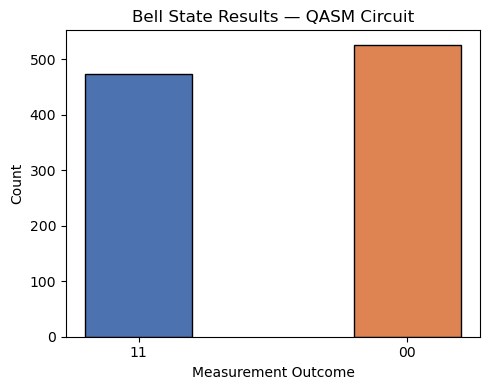

In [ ]:
# Plot as bar chart
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(counts.keys(), counts.values(), color=['#4C72B0', '#DD8452'], edgecolor='black', width=0.4)
ax.set_xlabel('Measurement Outcome')
ax.set_ylabel('Count')
ax.set_title('Bell State Results — QASM Circuit')
plt.tight_layout()
plt.show()

In [ ]:
# Create a simple 1-qubit circuit in superposition
qc3 = QuantumCircuit(1)
qc3.h(0)  # Hadamard: puts qubit into superposition

# Get the density matrix
dm = DensityMatrix(qc3)

print("Circuit:")
print(qc3.draw('text'))
print()
print("Density Matrix:")
print(np.round(dm.data, 4))

Circuit:
   ┌───┐
q: ┤ H ├
   └───┘

Density Matrix:
[[0.5+0.j 0.5+0.j]
 [0.5+0.j 0.5+0.j]]


In [ ]:
print("=== DIAGONAL ELEMENTS (Probabilities) ===")
print()

diag = np.diag(dm.data).real

print(f"ρ[0,0] = {diag[0]:.4f}  → Probability of measuring |0⟩ = {diag[0]*100:.0f}%")
print(f"ρ[1,1] = {diag[1]:.4f}  → Probability of measuring |1⟩ = {diag[1]*100:.0f}%")
print()
print(f"Sum of diagonal = {sum(diag):.1f}  (always equals 1 — total probability)")

=== DIAGONAL ELEMENTS (Probabilities) ===

ρ[0,0] = 0.5000  → Probability of measuring |0⟩ = 50%
ρ[1,1] = 0.5000  → Probability of measuring |1⟩ = 50%

Sum of diagonal = 1.0  (always equals 1 — total probability)


In [ ]:
print("=== OFF-DIAGONAL ELEMENTS (Quantum Coherence) ===")
print()

print(f"ρ[0,1] = {dm.data[0,1]:.4f}  → quantum coherence")
print(f"ρ[1,0] = {dm.data[1,0]:.4f}  → conjugate of ρ[0,1]")
print()
print("Non-zero off-diagonal = qubit is in SUPERPOSITION")
print("Zero off-diagonal     = classical state, no quantum behavior")

=== OFF-DIAGONAL ELEMENTS (Quantum Coherence) ===

ρ[0,1] = 0.5000+0.0000j  → quantum coherence
ρ[1,0] = 0.5000+0.0000j  → conjugate of ρ[0,1]

Non-zero off-diagonal = qubit is in SUPERPOSITION
Zero off-diagonal     = classical state, no quantum behavior


In [ ]:
# Classical state |0⟩ — no gates, no superposition
qc3b = QuantumCircuit(1)
dm_classical = DensityMatrix(qc3b)

print("=== COMPARISON: Classical |0⟩ state ===")
print()
print("Density Matrix of |0⟩:")
print(np.round(dm_classical.data, 4))
print()
print(f"Diagonal:     ρ[0,0]={np.diag(dm_classical.data).real[0]:.0f}  ρ[1,1]={np.diag(dm_classical.data).real[1]:.0f}")
print(f"Off-diagonal: ρ[0,1]={dm_classical.data[0,1]:.0f}  ρ[1,0]={dm_classical.data[1,0]:.0f}")
print()
print("All off-diagonal = 0 → no superposition → classical state")

=== COMPARISON: Classical |0⟩ state ===

Density Matrix of |0⟩:
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]

Diagonal:     ρ[0,0]=1  ρ[1,1]=0
Off-diagonal: ρ[0,1]=0+0j  ρ[1,0]=0+0j

All off-diagonal = 0 → no superposition → classical state


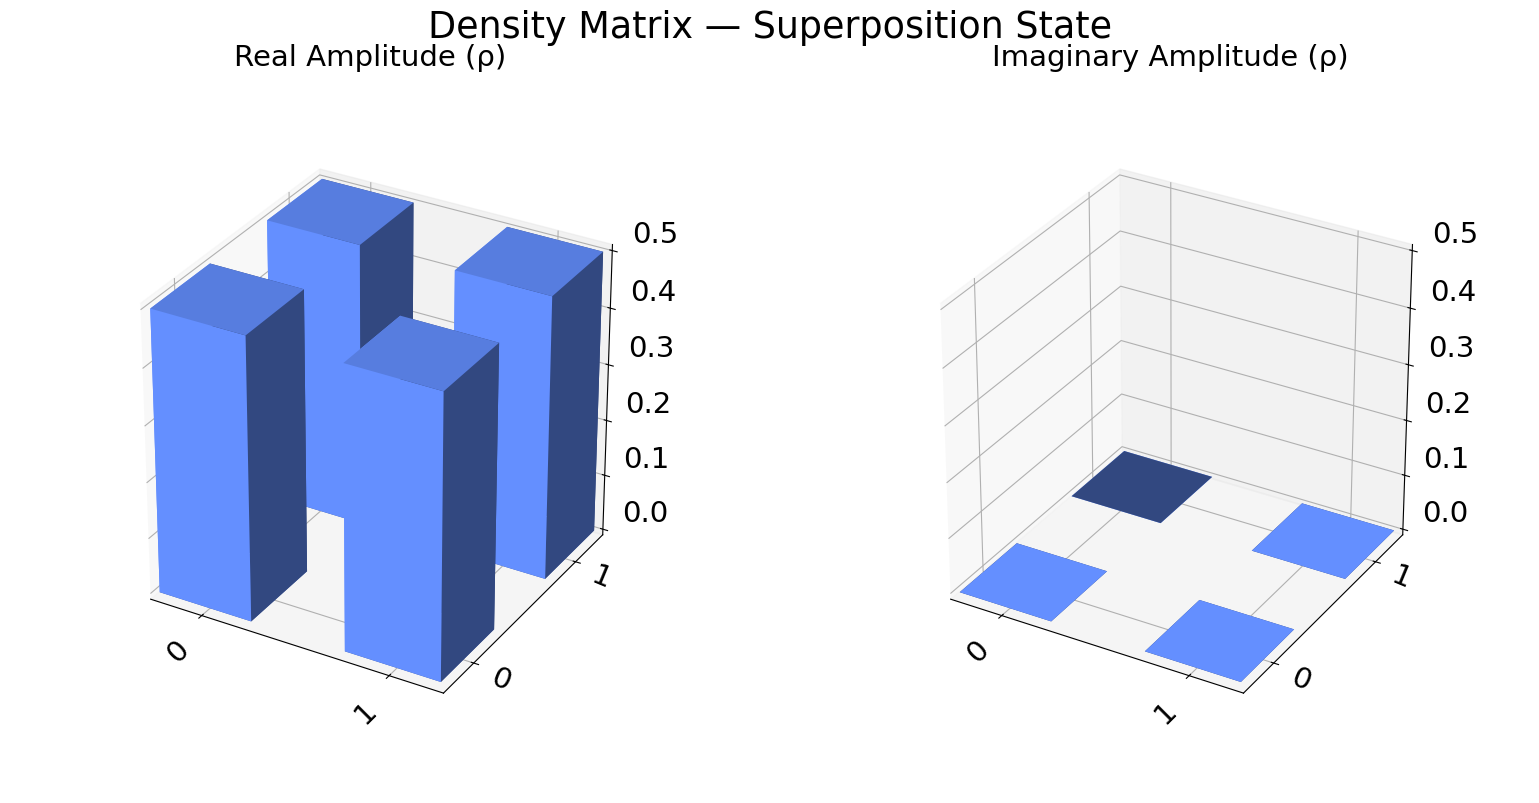

In [ ]:
from qiskit.visualization import plot_state_city

fig = plot_state_city(dm, title='Density Matrix — Superposition State')
fig

In [ ]:
# 3-qubit circuit using many different gate types
qc4 = QuantumCircuit(3, 3)  # 3 qubits, 3 classical bits

# Layer 1 - Superposition
qc4.h(0)
qc4.h(1)
qc4.x(2)          # X gate = NOT gate, flips |0⟩ to |1⟩
qc4.barrier()     # visual separator (not a gate)

# Layer 2 - Entanglement & Phase
qc4.cx(0, 1)      # CNOT: qubit 0 controls qubit 1
qc4.s(0)          # 90° phase shift on qubit 0
qc4.t(2)          # T gate = 45° phase shift on qubit 2
qc4.barrier()

# Layer 3 - More operations
qc4.ry(np.pi/4, 1)  # Rotate qubit 1 by 45° around Y axis
qc4.cz(1, 2)         # Controlled-Z gate
qc4.h(2)             # Hadamard on qubit 2
qc4.barrier()

# Measure all qubits
qc4.measure([0, 1, 2], [0, 1, 2])

print("Circuit built!")
print(f"Number of qubits : {qc4.num_qubits}")
print(f"Total gates      : {qc4.size()}")
print(f"Circuit depth    : {qc4.depth()}")

Circuit built!
Number of qubits : 3
Total gates      : 12
Circuit depth    : 7


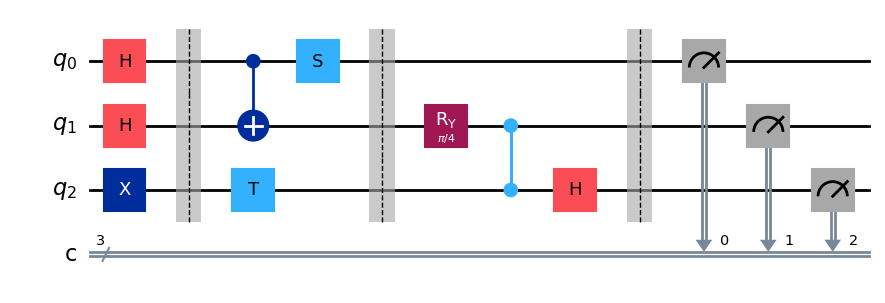

In [ ]:
# Draw using matplotlib 
fig = qc4.draw('mpl')
fig

In [ ]:
# Run on simulator
sim = AerSimulator()
compiled = transpile(qc4, sim)
result4 = sim.run(compiled, shots=1000).result()
counts4 = result4.get_counts()

print("Results after 1000 runs:")
print(counts4)

Results after 1000 runs:
{'101': 36, '011': 201, '111': 206, '000': 39, '010': 218, '001': 32, '100': 43, '110': 225}


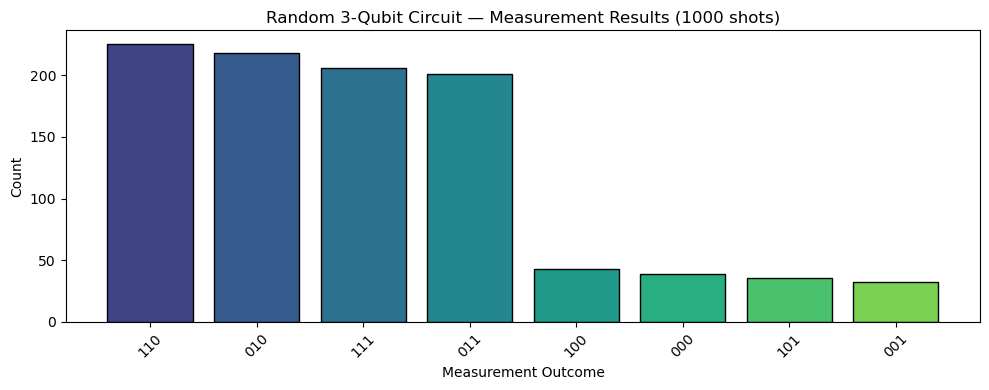

In [ ]:
# Plot the results
fig2, ax = plt.subplots(figsize=(10, 4))
sorted_counts = dict(sorted(counts4.items(), key=lambda x: -x[1]))

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(sorted_counts)))
ax.bar(sorted_counts.keys(), sorted_counts.values(),
       color=colors, edgecolor='black')

ax.set_xlabel('Measurement Outcome')
ax.set_ylabel('Count')
ax.set_title('Random 3-Qubit Circuit — Measurement Results (1000 shots)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
